# MNIST Pipeline — Run, Analyze, Plot

Self-contained guide for the MNIST **alpha experiments** at
`mnist_full_r12 / nat / legendre / d3r20c64` (Legendre embedding, in_dim 3,
bond_dim 20, complex64, 64-class) plus the matching adversarially-trained (`at`) model.

| Figure | What it shows |
|--------|---------------|
| Fig 1 | Sampling: per-class mean sampled digit (from the $\alpha=0.01$ model) |
| Fig 2 | Alpha curve: accuracy / robustness + NLL vs $\alpha$ |
| Fig 3 | Robustness curves: robust acc vs attack $\varepsilon$ — 4 models, plus per-model purification & detection overlays |

**Prerequisites**: `conda activate bm4tc`, launch Jupyter, run cells top-to-bottom.
The nat alpha sweeps are already trained + analyzed; `at` is yours to run (§0b).

**Sections**: §0 run · §0b at · §1 analyze + config · §2–4 figures.

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all outputs/analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/martin-lanigo/projects/bm4tc


In [2]:
import matplotlib

# Paper styling: Times New Roman via LaTeX (mathptmx). Requires a system LaTeX install
# (latex + dvipng); set USE_LATEX = False to fall back to matplotlib mathtext.
USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False})

PCT = r"\%" if USE_LATEX else "%"   # '%' is a comment char under usetex; escape it in labels

---
## §0  Run the nat alpha experiments

The 3-stage alpha-HPO pipeline: discriminative HPO ($\alpha=0$) → warm-started
generative HPO ladder (sweeps `lr` + `norm_control.soft_strength`) → fill best HPs
→ seed sweeps. These are **already trained** for the current state; the cell prints
the commands for reproduction. Run from the project root.

In [3]:
ARCH = "mnist_full_r12/nat/legendre/d3r20c64"
NAT_PRETRAINED = ["hpo_pretrained_a001", "hpo_pretrained_a01",
                  "hpo_pretrained_a02", "hpo_pretrained_a05", "hpo_pretrained_a1"]
SEED_SWEEPS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
               "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]

print("# Stage 1 - discriminative HPO (alpha=0, from scratch, sweeps lr):")
print(f"python -m experiments.train --multirun +experiments={ARCH}/hpo_a0")

print("\n# Stage 2 - warm-started generative HPO ladder (sweeps lr + soft_strength):")
print("#   first set +model_path=outputs/.../hpo_a0_DDMM/0/models/model in each config.")
for k in NAT_PRETRAINED:
    print(f"python -m experiments.train --multirun +experiments={ARCH}/{k}")

print("\n# Stage 3 - bake best HPs into the seed_sweep configs:")
print("python tools/fill_hpo.py --trainer nat --dataset mnist_full_r12 "
      "--embedding legendre --arch d3r20c64")

print("\n# Stage 3 - run the seed sweeps (5 seeds each):")
for k in SEED_SWEEPS:
    print(f"python -m experiments.train --multirun +experiments={ARCH}/{k}")

# Stage 1 - discriminative HPO (alpha=0, from scratch, sweeps lr):
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_a0

# Stage 2 - warm-started generative HPO ladder (sweeps lr + soft_strength):
#   first set +model_path=outputs/.../hpo_a0_DDMM/0/models/model in each config.
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a001
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a01
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a02
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a05
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a1

# Stage 3 - bake best HPs into the seed_sweep configs:
python tools/fill_hpo.py --trainer nat --dataset mnist_full_r12 --embedding legendr

---
## §0b  Run the adversarially-trained (`at`) model

The `at` model warm-starts from the best $\alpha=0$ checkpoint, so run it **after**
`seed_sweep_a0`. It is **not yet trained** — Fig 3's `AT` line stays absent until you do.

In [4]:
AT_ARCH = "mnist_full_r12/at/legendre/d3r20c64"
A0_DIR  = "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206"

print("# Step 1 - point the at configs' model_path at the real a0 run dir:")
print(f"python tools/patch_checkpoint.py {A0_DIR}")
print("#   (patches both at/hpo.yaml and at/seed_sweep.yaml by default)")

print("\n# Step 2 - [optional] at HPO + fill (skip if seed_sweep.yaml HPs are already filled):")
print(f"python -m experiments.train --multirun +experiments={AT_ARCH}/hpo")
print("python tools/fill_hpo.py --trainer at --dataset mnist_full_r12 "
      "--embedding legendre --arch d3r20c64")

print("\n# Step 3 - run the at seed sweep (5 seeds):")
print(f"python -m experiments.train --multirun +experiments={AT_ARCH}/seed_sweep")

# Step 1 - point the at configs' model_path at the real a0 run dir:
python tools/patch_checkpoint.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206
#   (patches both at/hpo.yaml and at/seed_sweep.yaml by default)

# Step 2 - [optional] at HPO + fill (skip if seed_sweep.yaml HPs are already filled):
python -m experiments.train --multirun +experiments=mnist_full_r12/at/legendre/d3r20c64/hpo
python tools/fill_hpo.py --trainer at --dataset mnist_full_r12 --embedding legendre --arch d3r20c64

# Step 3 - run the at seed sweep (5 seeds):
python -m experiments.train --multirun +experiments=mnist_full_r12/at/legendre/d3r20c64/seed_sweep


---
## §1  Analyze + configure output dirs

`analysis/sweep.py` turns each multirun output dir into an `evaluation_data.csv`
(one row per seed: `acc`, `rob/{eps}`, `uq_purify_acc/{eps}/{r}`, detection columns, NLL).
Pass `--viz` to also emit the best-run sampling plot used by Fig 1.

Fill `SWEEP_DIRS` with your dated output dirs (`{kind}_{DDMM}`). The nat entries below are
the current trained runs; `at_seed_sweep` is a placeholder — fill it after §0b.

In [5]:
# Dated output dirs ({kind}_{DDMM}). nat dirs are the current trained runs.
SWEEP_DIRS = {
    "seed_sweep_a0":   "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206",
    "seed_sweep_a001": "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206",
    "seed_sweep_a01":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a01_1206",
    "seed_sweep_a02":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a02_1306",
    "seed_sweep_a05":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a05_1306",
    "seed_sweep_a1":   "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a1_1206",
    "at_seed_sweep":   "outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep_1606",
}

# Alpha ladder: maps each nat seed sweep to its alpha value.
ALPHA_OF = {
    "seed_sweep_a0": 0.0, "seed_sweep_a001": 0.01, "seed_sweep_a01": 0.1,
    "seed_sweep_a02": 0.2, "seed_sweep_a05": 0.5, "seed_sweep_a1": 1.0,
}

VIZ_SWEEPS = {"seed_sweep_a001"}  # Fig 1 samples from the alpha=0.01 model

print("# Analysis commands (run from project root):")
for name, sweep_dir in SWEEP_DIRS.items():
    viz = " --viz" if name in VIZ_SWEEPS else ""
    print(f"python analysis/sweep.py {sweep_dir}{viz}")

# Analysis commands (run from project root):
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206 --viz
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a01_1206
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a02_1306
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a05_1306
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a1_1206
python analysis/sweep.py outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep_1606


---
## §2  Figure 1 — Sampling (the $\alpha=0.01$ model)

Per-class **mean** sampled digit in a 2×5 grid (digits 0–9), via
`analysis/visualize/mnist_samples.py`. Uses the best (highest clean-acc) run of the
$\alpha=0.01$ seed sweep — the smallest nonzero alpha, where samples first become legible.
Output: `figures/mnist/sampling/mnist_samples.png`.

> Sampling 785 sites is heavy on CPU; drop `n_per_class` for a quick check.

INFO:analysis.utils.mia_utils:Found checkpoint: /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4/models/model


Best alpha=0.01 run: /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4  (acc=0.9690, device=cuda)


INFO:analysis.visualize.mnist_samples:Loaded model from /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4/models/model


INFO:analysis.visualize.mnist_samples:Sampled 640 images (64 per class)


INFO:analysis.visualize.mnist_samples:Saved to /home/martin-lanigo/projects/bm4tc/figures/mnist/sampling/mnist_samples.png


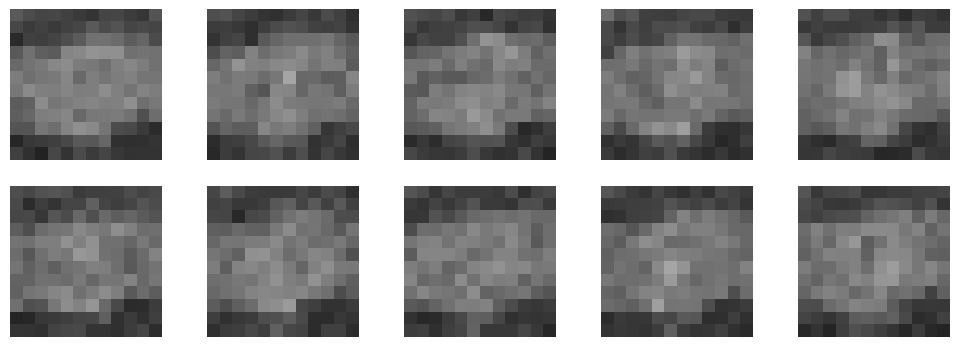

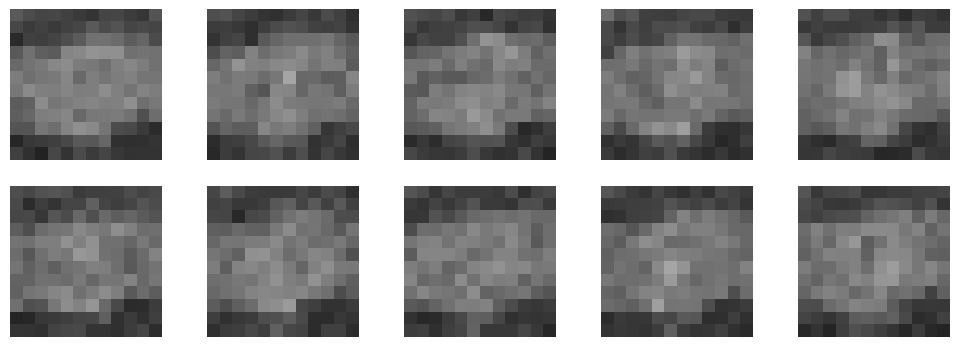

In [6]:
import pandas as pd
import torch
from analysis.utils import get_best_run
from analysis.visualize.mnist_samples import sample_and_plot

SAMPLE_KEY = "seed_sweep_a001"   # alpha = 0.01
N_PER_CLASS = 64                 # lower (e.g. 8) for a fast sanity check
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # force "cpu" if your CUDA runtime is stale

csv  = PROJECT_ROOT / "analysis" / SWEEP_DIRS[SAMPLE_KEY] / "evaluation_data.csv"
df   = pd.read_csv(csv)
best = get_best_run(df, "acc", minimize=False)            # highest clean accuracy
run_dir = PROJECT_ROOT / SWEEP_DIRS[SAMPLE_KEY] / str(best["run_name"])
print(f"Best alpha=0.01 run: {run_dir}  (acc={best['acc']:.4f}, device={DEVICE})")

save_dir = PROJECT_ROOT / "figures/mnist/sampling"
fig = sample_and_plot(str(run_dir), n_per_class=N_PER_CLASS, save_dir=str(save_dir), device=DEVICE)

# Strip titles for paper inclusion (sample_and_plot adds a suptitle + per-cell "Digit c"
# labels; cells are row-major 0-9), then re-save over the file it wrote.
fig.suptitle("")
for ax in fig.axes:
    ax.set_title("")
fig.savefig(save_dir / "mnist_samples.png", dpi=150, bbox_inches="tight")
fig   # display inline

---
## §3  Figure 2 — Alpha curve (two figures)

Assembled from the six nat seed sweeps ($\alpha \in \{0, 0.01, 0.1, 0.2, 0.5, 1\}$),
aggregated over seeds (mean ± **1 std** band). Split into two standalone figures:

- **Accuracy** (`alpha_curve_accuracy.png`) — Clean, Rob. and Purif. (lk.) accuracy vs $\alpha$
  at $\varepsilon = 0.3$ (symlog x-axis).
- **NLL** (`alpha_curve_nll.png`) — discriminative vs generative NLL vs $\alpha$ (dual axes).

Missing columns are skipped silently.

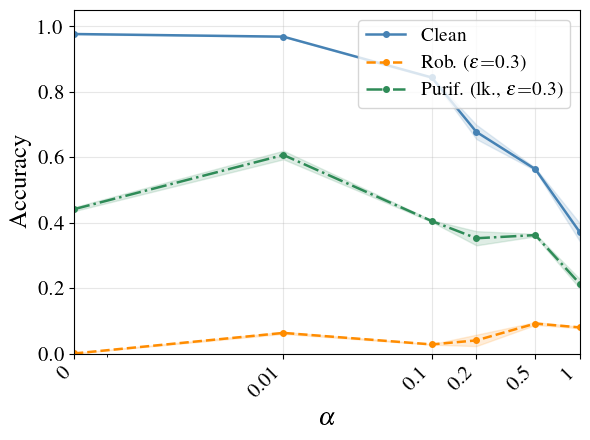

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/alpha/alpha_curve_accuracy.png


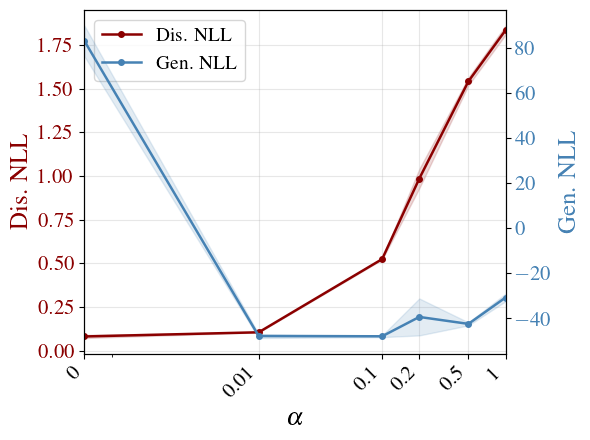

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/alpha/alpha_curve_nll.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EPS_ALPHA = 0.3                                   # attack budget for the robustness lines
ACC_COL   = "acc"
ROB_COL   = f"rob/{EPS_ALPHA}"
PURIF_COL = f"uq_purify_acc/{EPS_ALPHA}/0.2"
DIS_COL, GEN_COL = "dis_loss", "gen_loss"
LABEL_FS, TICK_FS, LEG_FS = 18, 15, 14            # axis label / tick / legend font sizes

NAT_KEYS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
            "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]

rows = []
for key in NAT_KEYS:
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    if not p.exists():
        print(f"skip (missing): {p}"); continue
    d = pd.read_csv(p)
    d["alpha"] = ALPHA_OF[key]
    rows.append(d)
df = pd.concat(rows, ignore_index=True)


def agg(col):
    """Return (alpha, mean, 1-std) aggregated over seeds; None if column absent."""
    if col not in df.columns:
        return None
    g = df.groupby("alpha")[col].agg(["mean", "std"]).sort_index()
    return g.index.values, g["mean"].values, g["std"].fillna(0).values


def plot_line(ax, res, label, color, ls="-"):
    if res is None:
        return
    a, m, s = res
    ax.plot(a, m, color=color, linestyle=ls, linewidth=1.8, marker="o", ms=4, label=label)
    ax.fill_between(a, m - s, m + s, color=color, alpha=0.15)   # ±1 std band


_TICKS  = [0, 0.01, 0.1, 0.2, 0.5, 1.0]
_LABELS = ["0", "0.01", "0.1", "0.2", "0.5", "1"]


def setup_xaxis(ax):
    ax.set_xscale("symlog", linthresh=5e-3)
    ax.set_xlim(0, 1)
    ax.set_xticks(_TICKS)
    ax.set_xticklabels(_LABELS, rotation=45, ha="right", fontsize=TICK_FS)


outdir = PROJECT_ROOT / "figures/mnist/alpha"
outdir.mkdir(parents=True, exist_ok=True)

# --- Figure A: accuracy vs alpha ---
figA, ax = plt.subplots(figsize=(6, 4.5))
plot_line(ax, agg(ACC_COL),   "Clean",                                       "steelblue",  "-")
plot_line(ax, agg(ROB_COL),   rf"Rob. ($\varepsilon{{=}}{EPS_ALPHA}$)",       "darkorange", "--")
plot_line(ax, agg(PURIF_COL), rf"Purif. (lk., $\varepsilon{{=}}{EPS_ALPHA}$)", "seagreen",  "-.")
ax.set_xlabel(r"$\alpha$", fontsize=LABEL_FS); ax.set_ylabel("Accuracy", fontsize=LABEL_FS)
ax.tick_params(axis="y", labelsize=TICK_FS)
setup_xaxis(ax); ax.set_ylim(0, 1.05); ax.legend(fontsize=LEG_FS); ax.grid(True, alpha=0.3)
figA.tight_layout()
outA = outdir / "alpha_curve_accuracy.png"
figA.savefig(outA, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved {outA}")

# --- Figure B: NLL vs alpha (dual axes) ---
figB, axl = plt.subplots(figsize=(6, 4.5))
axr = axl.twinx()
plot_line(axl, agg(DIS_COL), "Dis. NLL", "darkred",   "-")
plot_line(axr, agg(GEN_COL), "Gen. NLL", "steelblue", "-")
axl.set_xlabel(r"$\alpha$", fontsize=LABEL_FS)
axl.set_ylabel("Dis. NLL", color="darkred", fontsize=LABEL_FS)
axr.set_ylabel("Gen. NLL", color="steelblue", fontsize=LABEL_FS)
axl.tick_params(axis="y", labelcolor="darkred", labelsize=TICK_FS)
axr.tick_params(axis="y", labelcolor="steelblue", labelsize=TICK_FS)
setup_xaxis(axl); axl.grid(True, alpha=0.3)
lines = axl.get_lines() + axr.get_lines()
if lines:
    axl.legend(lines, [l.get_label() for l in lines], fontsize=LEG_FS)
figB.tight_layout()
outB = outdir / "alpha_curve_nll.png"
figB.savefig(outB, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved {outB}")

---
## §4  Figure 3 — Defense comparison (model × defense, per attack strength)

One standalone grouped bar chart **per attack $\varepsilon$** ($\varepsilon$ encoded in the
filename). Within each: x = model ($\alpha=0,\,0.01,\,0.5$, and `AT`), bar groups compare
defenses, mean ± **1 std** over seeds. Labels match the 2dtoy figures:

- **Clean** — clean accuracy reference (`acc`, $\varepsilon$-independent).
- **Rob.** — undefended adversarial accuracy (`rob/{eps}`).
- **Purif. (lk.)** — likelihood purification (`uq_purify_acc/{eps}/0.2`).
- **Accept ($q{=}10\%$)** — accuracy on inputs the likelihood detector does *not* flag,
  $1-$`uq_det_err_passed/10pct/{eps}` (threshold = 10th percentile of clean $\log p(x)$,
  i.e. ~10% of clean inputs rejected). *Conditional on acceptance* — at large $\varepsilon$
  more inputs are rejected (see `uq_detection/10pct/{eps}` for coverage).

> `uq_joint_*` columns are accuracy under a detector-aware *adaptive* attack, **not** a
> defense — not plotted. Models with no CSV yet (`AT` before §0b) are skipped.
> Outputs: `figures/mnist/robustness/defense_comparison_eps{0.1,0.2,0.3}.png`.

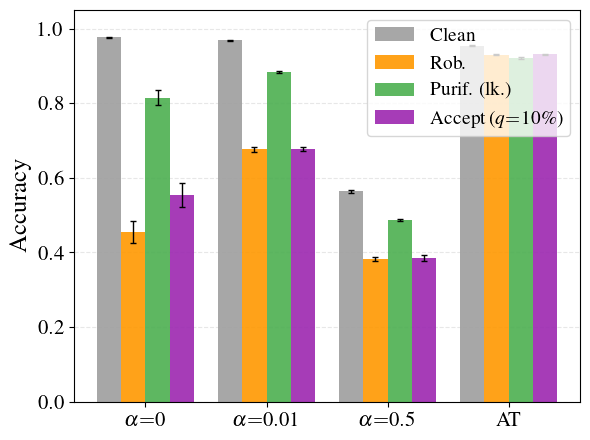

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.1.png


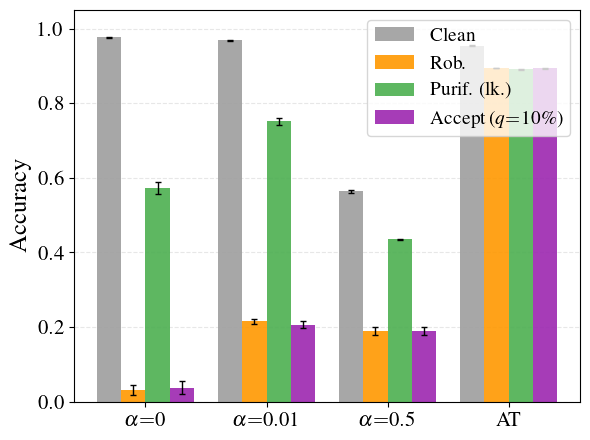

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.2.png


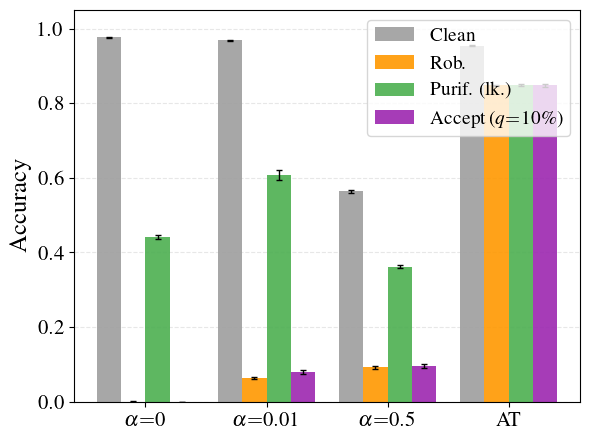

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.3.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Models to compare (x-axis). Defenses are the bar groups.
MODELS = [
    ("seed_sweep_a0",   r"$\alpha{=}0$"),
    ("seed_sweep_a001", r"$\alpha{=}0.01$"),
    ("seed_sweep_a05",  r"$\alpha{=}0.5$"),
    ("at_seed_sweep",   "AT"),
]
# (label, color, column template, flip = use 1 - value). Labels match the 2dtoy figures.
# Accept = accuracy on inputs the detector does NOT flag = 1 - uq_det_err_passed/10pct/{eps}
# (threshold at the 10th percentile of clean log p(x), i.e. ~10% of clean inputs rejected).
DEFENSES = [
    ("Clean",                  "#9E9E9E", "acc",                           False),
    ("Rob.",                   "#FF9800", "rob/{eps}",                     False),
    ("Purif. (lk.)",           "#4CAF50", "uq_purify_acc/{eps}/0.2",       False),
    (rf"Accept ($q{{=}}10{PCT}$)", "#9C27B0", "uq_det_err_passed/10pct/{eps}", True),
]

LABEL_FS, TICK_FS, LEG_FS = 18, 15, 14   # axis label / tick / legend font sizes


def load(key):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    return pd.read_csv(p) if p.exists() else None


def eps_grid(df):
    eps = set()
    for c in df.columns:
        if c.startswith("rob/"):
            try:
                eps.add(float(c.split("/")[1]))
            except ValueError:
                pass
    return sorted(eps)


def stat(df, template, eps, flip):
    """Mean and 1-std over seeds for one (defense, eps); NaN if column absent."""
    col = template.format(eps=eps)
    if col not in df.columns:
        return np.nan, 0.0
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if flip:
        v = 1.0 - v
    return (v.mean(), v.std() if len(v) > 1 else 0.0)


dfs = {k: load(k) for k, _ in MODELS}
for k, _ in MODELS:
    if dfs[k] is None:
        print(f"skip (no CSV yet): {k}")
avail = [(k, lab) for k, lab in MODELS if dfs[k] is not None]
EPS_LIST = eps_grid(dfs[avail[0][0]])

n_m, n_d = len(avail), len(DEFENSES)
x, width = np.arange(n_m), 0.8 / n_d
outdir = PROJECT_ROOT / "figures/mnist/robustness"
outdir.mkdir(parents=True, exist_ok=True)

# One standalone figure per attack epsilon (eps encoded in the filename).
for eps in EPS_LIST:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for j, (dlabel, dcolor, tmpl, flip) in enumerate(DEFENSES):
        means, stds = zip(*(stat(dfs[k], tmpl, eps, flip) for k, _ in avail))
        ax.bar(x + (j - (n_d - 1) / 2) * width, means, width, yerr=stds,
               label=dlabel, color=dcolor, capsize=2, alpha=0.9,
               error_kw={"elinewidth": 1})
    ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in avail], fontsize=TICK_FS)
    ax.set_ylabel("Accuracy", fontsize=LABEL_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3, ls="--"); ax.set_axisbelow(True)
    ax.legend(fontsize=LEG_FS, loc="upper right")
    fig.tight_layout()
    out = outdir / f"defense_comparison_eps{eps}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved {out}")

---
## §5  Tables (LaTeX + plain text)

Two tables for the four models ($\alpha=0,\,0.01,\,0.5$, and AT), written to
`figures/mnist/tables/` as `.tex` (booktabs — the consuming document needs
`\usepackage{booktabs,multirow}`) and human-readable `.txt`. Ported from
`reference/detection_tables.py` and `reference/toy_analysis.py`.

- **Detection table** (`detection.tex` / `.txt`): per model — Clean / Rob. / Purif. (lk.) /
  Det. rate ($q{=}10\%$) / Accept. ($q{=}10\%$) across $\varepsilon\in\{0.1,0.2,0.3\}$;
  best model per (metric, $\varepsilon$) in **bold**. (`Accept. = 1 - uq_det_err_passed/10pct`.)
- **Joint-vs-normal $\Delta$ tables** (`joint_vs_normal_eps{eps}.tex`, one per $\varepsilon$,
  + combined `joint_vs_normal.txt`): mean$\pm$std of (**joint adaptive** $-$ **standard**
  attack) per metric × model. Negative $\Rightarrow$ the detector-aware joint attack is stronger.

In [9]:
import numpy as np
import pandas as pd

# Four models matching the defense figure (row-groups / columns of the tables).
TABLE_MODELS = [
    ("seed_sweep_a0",   r"$\alpha{=}0$"),
    ("seed_sweep_a001", r"$\alpha{=}0.01$"),
    ("seed_sweep_a05",  r"$\alpha{=}0.5$"),
    ("at_seed_sweep",   "AT"),
]
EPSILONS = [0.1, 0.2, 0.3]
DET_PCT, RADIUS = "10pct", 0.2

tables_dir = PROJECT_ROOT / "figures/mnist/tables"
tables_dir.mkdir(parents=True, exist_ok=True)


def _tload(key):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    return pd.read_csv(p) if p.exists() else None


def _ms(df, col, flip=False):
    if df is None or col not in df.columns:
        return float("nan"), float("nan")
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(v) == 0:
        return float("nan"), float("nan")
    m = 1.0 - v.mean() if flip else v.mean()
    return float(m), float(v.std() if len(v) > 1 else 0.0)


def _tex(m, s, bold=False, signed=False):
    if np.isnan(m):
        return "---"
    num = f"{m:+.3f}" if signed else f"{m:.3f}"
    body = f"{num} \\pm {s:.3f}" if (not np.isnan(s) and s != 0.0) else num
    return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"


def _plain(m, s, best=False, signed=False):
    if np.isnan(m):
        return "---"
    num = f"{m:+.3f}" if signed else f"{m:.3f}"
    body = f"{num}±{s:.3f}" if (not np.isnan(s) and s != 0.0) else num
    return body + ("*" if best else "")


def _strip(t):  # crude LaTeX -> plain for the .txt preview
    return (t.replace(r"\ ", " ").replace(r"\%", "%").replace("$", "").replace("{=}", "=")
            .replace(r"\alpha", "a").replace(r"\varepsilon", "eps").replace(r"\mathbf", "")
            .replace("{", "").replace("}", ""))


T_DFS = [(lab, _tload(k)) for k, lab in TABLE_MODELS]

# --- Detection table: models x (metric, eps), best per (metric, eps) in bold ---
# (row label, column template, eps-dependent, flip = use 1 - value)
DET_METRICS = [
    ("Clean",                    "acc",                                  False, False),
    (r"Rob.",                    "rob/{eps}",                            True,  False),
    (r"Purif.\ (lk.)",           f"uq_purify_acc/{{eps}}/{RADIUS}",      True,  False),
    (r"Det.\ rate ($q{=}10\%$)", f"uq_detection/{DET_PCT}/{{eps}}",      True,  False),
    (r"Accept.\ ($q{=}10\%$)",   f"uq_det_err_passed/{DET_PCT}/{{eps}}", True,  True),
]

data = []
for _, df in T_DFS:
    md = []
    for _, tpl, eps_dep, flip in DET_METRICS:
        md.append([_ms(df, tpl, flip)] if not eps_dep
                  else [_ms(df, tpl.format(eps=e), flip) for e in EPSILONS])
    data.append(md)
best = []
for r in range(len(DET_METRICS)):
    rb = []
    for e in range(len(data[0][r])):
        means = [data[m][r][e][0] for m in range(len(T_DFS))]
        valid = [(v, i) for i, v in enumerate(means) if not np.isnan(v)]
        rb.append(max(valid)[1] if valid else -1)
    best.append(rb)

L = [r"\begin{tabular}{@{}llrrr@{}}", r"\toprule",
     r"Model & Metric & " + " & ".join(f"$\\varepsilon={e}$" for e in EPSILONS) + r" \\",
     r"\midrule"]
for m, (lab, _) in enumerate(T_DFS):
    for r, (rl, _, eps_dep, _) in enumerate(DET_METRICS):
        mc = f"\\multirow{{{len(DET_METRICS)}}}{{*}}{{{lab}}}" if r == 0 else ""
        slots = data[m][r]
        if not eps_dep:
            L.append(f"{mc} & {rl} & \\multicolumn{{3}}{{c}}{{{_tex(*slots[0], bold=(best[r][0] == m))}}} \\\\")
        else:
            cells = [_tex(*slots[e], bold=(best[r][e] == m)) for e in range(len(EPSILONS))]
            L.append(f"{mc} & {rl} & " + " & ".join(cells) + r" \\")
    if m < len(T_DFS) - 1:
        L.append(r"\cmidrule(lr){1-5}")
L += [r"\bottomrule", r"\end{tabular}"]
(tables_dir / "detection.tex").write_text("\n".join(L) + "\n")

cw, ew = 24, 18
hdr = f"{'Model':<22}{'Metric':<{cw}}" + "".join(f"eps={e:<{ew - 4}}" for e in EPSILONS)
P = [hdr, "-" * len(hdr)]
for m, (lab, _) in enumerate(T_DFS):
    for r, (rl, _, eps_dep, _) in enumerate(DET_METRICS):
        ml = _strip(lab) if r == 0 else ""
        slots = data[m][r]
        if not eps_dep:
            P.append(f"{ml:<22}{_strip(rl):<{cw}}" + _plain(*slots[0], best=(best[r][0] == m)))
        else:
            cells = [_plain(*slots[e], best=(best[r][e] == m)) for e in range(len(EPSILONS))]
            P.append(f"{ml:<22}{_strip(rl):<{cw}}" + "".join(f"{c:<{ew}}" for c in cells))
    P.append("-" * len(hdr))
(tables_dir / "detection.txt").write_text("\n".join(P) + "\n")
print("Saved detection.tex and detection.txt\n")
print("\n".join(P))

Saved detection.tex and detection.txt

Model                 Metric                  eps=0.1           eps=0.2           eps=0.3           
----------------------------------------------------------------------------------------------------
a=0                   Clean                   0.977±0.001*
                      Rob.                    0.455±0.030       0.032±0.013       0.000±0.000       
                      Purif. (lk.)            0.815±0.020       0.574±0.016       0.441±0.006       
                      Det. rate (q=10%)       0.294±0.028*      0.287±0.036*      0.207±0.031       
                      Accept. (q=10%)         0.554±0.033       0.038±0.016       0.000±0.000       
----------------------------------------------------------------------------------------------------
a=0.01                Clean                   0.969±0.000
                      Rob.                    0.677±0.007       0.215±0.006       0.063±0.003       
                      Purif. (lk.)  

In [10]:
# Joint (adaptive) minus standard attack: Delta = joint - normal. One table per eps.
# (joint col template, normal col template, row label). Delta is joint - normal for ALL rows
# (the toy reference had the Accept/err-passed pair swapped; fixed here). Det. uses the
# detection RATE (always defined) rather than err-among-detected (NaN once the joint attack
# evades the detector).
JN_METRICS = [
    ("uq_joint_adv_acc/{eps}",                    "uq_adv_acc/{eps}",                    r"Rob."),
    (f"uq_joint_purify_acc/{{eps}}/{RADIUS}",     f"uq_purify_acc/{{eps}}/{RADIUS}",     r"Purif.\ (lk.)"),
    (f"uq_joint_detection/{DET_PCT}/{{eps}}",     f"uq_detection/{DET_PCT}/{{eps}}",     r"Det.\ rate ($q{=}10\%$)"),
    (f"uq_joint_det_err_passed/{DET_PCT}/{{eps}}", f"uq_det_err_passed/{DET_PCT}/{{eps}}", r"Accept.\ err ($q{=}10\%$)"),
]


def _delta(df, jcol, ncol):
    if df is None or jcol not in df.columns or ncol not in df.columns:
        return float("nan"), float("nan")
    d = pd.to_numeric(df[jcol], errors="coerce").values - pd.to_numeric(df[ncol], errors="coerce").values
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return float("nan"), float("nan")
    return float(d.mean()), float(d.std() if len(d) > 1 else 0.0)


align = "l" + "c" * len(T_DFS)
col_headers = " & ".join(["Metric"] + [lab for lab, _ in T_DFS])
plain_all = []
for eps in EPSILONS:
    L = [r"\begin{table}[htbp]", r"  \centering", f"  \\begin{{tabular}}{{{align}}}",
         r"    \toprule", f"    {col_headers} \\\\", r"    \midrule"]
    plain = [f"=== eps={eps} ===", f"{'Metric':<26}" + "".join(f"{_strip(l):<18}" for l, _ in T_DFS)]
    for jt, nt, hdr in JN_METRICS:
        cells = [_delta(df, jt.format(eps=eps), nt.format(eps=eps)) for _, df in T_DFS]
        L.append("    " + " & ".join([hdr] + [_tex(m, s, signed=True) for m, s in cells]) + r" \\")
        plain.append(f"{_strip(hdr):<26}" + "".join(f"{_plain(m, s, signed=True):<18}" for m, s in cells))
    L += [r"    \bottomrule", r"  \end{tabular}",
          rf"  \caption{{Difference (joint adaptive minus standard attack) at $\varepsilon={eps}$, "
          rf"$q{{=}}10\%$, MNIST, Legendre $d{{=}}3$, $r{{=}}20$. "
          r"Negative $\Rightarrow$ the detector-aware joint attack is stronger (lower accuracy / "
          r"lower detection rate).}",
          rf"  \label{{tab:joint_vs_normal_mnist_eps{eps}}}", r"\end{table}"]
    (tables_dir / f"joint_vs_normal_eps{eps}.tex").write_text("\n".join(L) + "\n")
    plain_all += plain + [""]
(tables_dir / "joint_vs_normal.txt").write_text("\n".join(plain_all) + "\n")
print("Saved joint_vs_normal_eps{0.1,0.2,0.3}.tex and joint_vs_normal.txt\n")
print("\n".join(plain_all))

Saved joint_vs_normal_eps{0.1,0.2,0.3}.tex and joint_vs_normal.txt

=== eps=0.1 ===
Metric                    a=0               a=0.01            a=0.5             AT                
Rob.                      +0.374±0.030      -0.002±0.015      -0.207±0.006      +0.016±0.001      
Purif. (lk.)              +0.085±0.010      +0.051±0.002      +0.036±0.001      +0.010±0.001      
Det. rate (q=10%)         -0.294±0.025      -0.164±0.005      -0.096±0.003      -0.122±0.010      
Accept. err (q=10%)       -0.276±0.032      +0.003±0.014      +0.211±0.007      -0.015±0.001      

=== eps=0.2 ===
Metric                    a=0               a=0.01            a=0.5             AT                
Rob.                      +0.545±0.012      +0.185±0.010      -0.086±0.009      +0.042±0.001      
Purif. (lk.)              +0.226±0.007      +0.177±0.006      +0.084±0.003      +0.030±0.001      
Det. rate (q=10%)         -0.287±0.032      -0.275±0.004      -0.194±0.004      -0.158±0.024      
Accept. 

---
## §6  Figure 4 — OOD-detection effectiveness vs threshold

One standalone figure **per model** ($\alpha=0$, $\alpha=0.01$, and `AT`) showing how the
likelihood detector's defense scales with its rejection threshold $q$ = percentile of clean
$\log p(x)$ (reject the lowest-likelihood $\sim q\%$ of inputs); points at $q \in \{0,1,5,10,20\}$.

- **left y** (solid, ○) — accuracy on **accepted** (non-flagged) inputs,
  $1-$`uq_det_err_passed/{q}pct/{eps}` (same "Accept" quantity as §4); $q=0$ anchor uses
  `uq_adv_acc/{eps}` (accept everything).
- **right y** (dashed, ■) — **detection rate** `uq_detection/{q}pct/{eps}` (fraction of
  adversarial inputs flagged); $q=0$ anchor = 0.
- **colour** = PGD $\varepsilon \in \{0.1, 0.2, 0.3\}$ (one per curve); mean ± **1 std** over seeds.

Effective detection ⇒ accuracy on accepted rises *and* detection rate climbs with $q$. All
data comes straight from the per-sweep `evaluation_data.csv`. Outputs:
`figures/mnist/detection/accept_acc_vs_threshold_{key}.png`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# One standalone figure per model: how the likelihood detector's defense scales with its
# rejection threshold q = percentile of clean log p(x) (reject the lowest-likelihood ~q%).
#   LEFT  y (solid, o)  : accuracy on ACCEPTED (non-flagged) inputs,
#                         1 - uq_det_err_passed/{q}pct/{eps}  (same "Accept" quantity as Fig 3).
#                         q=0 anchor (accept all) = uq_adv_acc/{eps} (full adv-set accuracy).
#   RIGHT y (dashed, s) : detection rate, uq_detection/{q}pct/{eps} (fraction of adv inputs
#                         flagged); q=0 anchor = 0 (nothing rejected).
# One curve per PGD epsilon (colour); mean +/- 1 std over the 5 seeds. Effective detection =>
# accuracy rises and detection rate climbs with q.
DET_SWEEPS = [
    ("seed_sweep_a0",   r"$\alpha{=}0$"),
    ("seed_sweep_a001", r"$\alpha{=}0.01$"),
    ("at_seed_sweep",   "AT"),
]
PERCENTILES = [1, 5, 10, 20]                        # clean-rejection quantiles stored in the CSV
EPSILONS    = [0.1, 0.2, 0.3]                        # PGD budgets -> one colour each
EPS_COLORS  = {0.1: "steelblue", 0.2: "darkorange", 0.3: "seagreen"}
LABEL_FS, TICK_FS, LEG_FS = 18, 15, 14              # axis label / tick / legend font sizes


def _load(key):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    return pd.read_csv(p) if p.exists() else None


def _curve(df, eps, q0_col, tmpl, flip=False):
    """(q, mean, std) over seeds vs rejection percentile q, with a q=0 anchor.

    q=0 uses q0_col (or 0.0 if absent); q>0 uses tmpl.format(q=q, eps=eps), 1 - value if flip.
    NaN-safe per cell 14's convention (a column/cell may be absent or NaN).
    """
    qs, means, stds = [], [], []
    if q0_col is None:                              # detection: nothing rejected at q=0
        qs.append(0.0); means.append(0.0); stds.append(0.0)
    elif q0_col in df.columns:
        v = pd.to_numeric(df[q0_col], errors="coerce").to_numpy()
        qs.append(0.0); means.append(np.nanmean(v)); stds.append(np.nanstd(v))
    for q in PERCENTILES:
        col = tmpl.format(q=q, eps=eps)
        if col not in df.columns:
            continue
        v = pd.to_numeric(df[col], errors="coerce").to_numpy()
        if flip:
            v = 1.0 - v
        qs.append(float(q)); means.append(np.nanmean(v)); stds.append(np.nanstd(v))
    return np.array(qs), np.array(means), np.nan_to_num(np.array(stds))


outdir = PROJECT_ROOT / "figures/mnist/detection"
outdir.mkdir(parents=True, exist_ok=True)

for key, model_lab in DET_SWEEPS:
    df = _load(key)
    if df is None:
        print(f"skip (no CSV yet): {key}"); continue
    fig, axl = plt.subplots(figsize=(6, 4.5))
    axr = axl.twinx()
    eps_handles = []
    for eps in EPSILONS:
        c = EPS_COLORS[eps]
        # left: accuracy on accepted (solid, circle)
        q, m, s = _curve(df, eps, f"uq_adv_acc/{eps}", "uq_det_err_passed/{q}pct/{eps}", flip=True)
        if len(q):
            (ln,) = axl.plot(q, m, color=c, ls="-", lw=1.8, marker="o", ms=4,
                             label=rf"$\varepsilon{{=}}{eps}$")
            axl.fill_between(q, m - s, m + s, color=c, alpha=0.15)
            eps_handles.append(ln)
        # right: detection rate (dashed, square)
        q, m, s = _curve(df, eps, None, "uq_detection/{q}pct/{eps}")
        if len(q):
            axr.plot(q, m, color=c, ls="--", lw=1.6, marker="s", ms=4)
            axr.fill_between(q, m - s, m + s, color=c, alpha=0.10)

    axl.set_xlabel(r"Rejection threshold $q$ (clean percentile, " + PCT + ")", fontsize=LABEL_FS)
    axl.set_ylabel("Accuracy on accepted", fontsize=LABEL_FS)
    axr.set_ylabel("Detection rate", fontsize=LABEL_FS)
    axl.tick_params(axis="both", labelsize=TICK_FS)
    axr.tick_params(axis="y", labelsize=TICK_FS)
    axl.set_ylim(0, 1.05); axr.set_ylim(0, 1.05); axl.grid(True, alpha=0.3)

    # Two legends: colour = epsilon (titled with the model), linestyle = metric.
    style_handles = [
        Line2D([], [], color="gray", ls="-", marker="o", ms=4, label="Acc. accepted"),
        Line2D([], [], color="gray", ls="--", marker="s", ms=4, label="Det. rate"),
    ]
    leg1 = axl.legend(handles=eps_handles, fontsize=LEG_FS, title=model_lab,
                      title_fontsize=LEG_FS, loc="upper left")
    axl.add_artist(leg1)
    axl.legend(handles=style_handles, fontsize=LEG_FS - 1, loc="lower right")
    fig.tight_layout()
    out = outdir / f"accept_acc_vs_threshold_{key}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved {out}")
